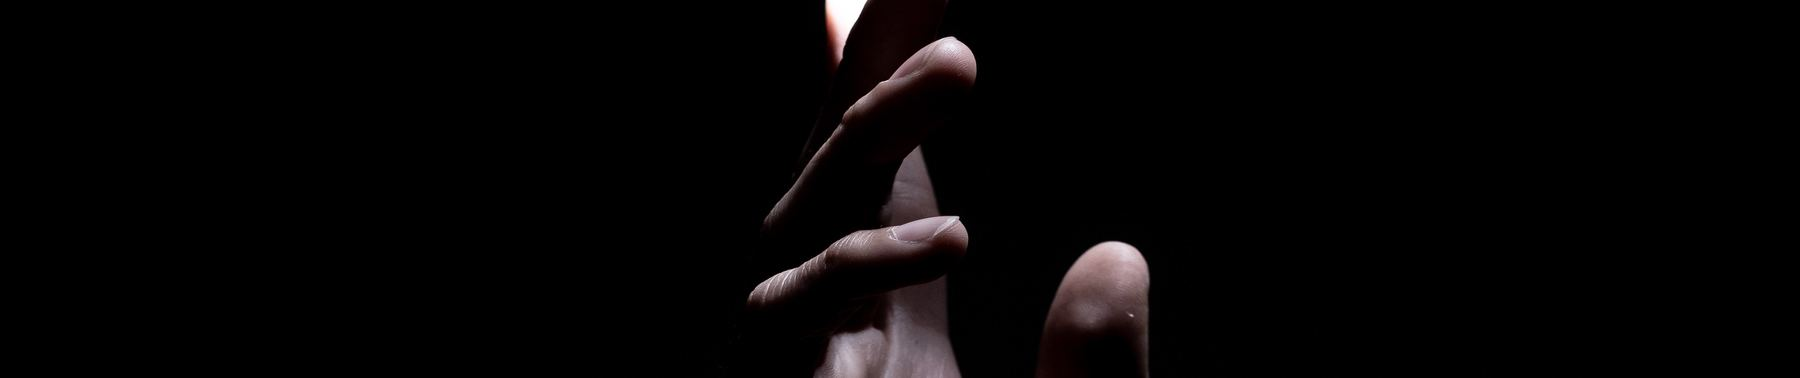

**[SOCOFing](https://www.kaggle.com/ruizgara/socofing):
Sokoto Coventry Fingerprint Dataset (SOCOFing)**

**Sokoto Coventry Fingerprint Dataset (SOCOFing) is a biometric fingerprint database designed for academic research purposes. SOCOFing is made up of 6,000 fingerprint images from 600 African subjects and contains unique attributes such as labels for gender, hand and finger name as well as synthetically altered versions with three different levels of alteration for obliteration, central rotation, and z-cut. For a complete formal description and usage policy please refer to the following paper: https://arxiv.org/abs/1807.10609**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import pickle
import cv2
import os
import tensorflow as tf
import zipfile
from tensorflow import keras
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, mean_squared_error, confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.exceptions import ConvergenceWarning
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.models import Model
from tensorflow.keras.preprocessing import image
from matplotlib.ticker import FuncFormatter

%matplotlib inline
np.random.seed(1)

warnings.filterwarnings("ignore", category=ConvergenceWarning) 

**Processo de download automático dos dados**

In [2]:
!pip install --upgrade --no-cache-dir gdown

In [3]:
!gdown --id '1nnGH9uKyhxDZ_T2Lm1s-m6CSmt48t5Hd'

Downloading...
From: https://drive.google.com/uc?id=1nnGH9uKyhxDZ_T2Lm1s-m6CSmt48t5Hd
To: /content/SOCOFing.zip
100% 434M/434M [00:02<00:00, 216MB/s]


In [2]:
with zipfile.ZipFile('SOCOFing.zip', 'r') as zip_ref:
    zip_ref.extractall('SOCOFing')

In [3]:
img_size = 96
def carregarimagens(pasta,label):
  x = list()
  for img in os.listdir(pasta):
      img_array = cv2.imread(os.path.join(pasta, img), cv2.IMREAD_GRAYSCALE)
      img_resize = cv2.resize(img_array, (img_size, img_size))
      x.append(img_resize)

  y = np.full((len(os.listdir(pasta))),label)

  return x,y

In [4]:
x_easy,y_easy = carregarimagens('SOCOFing/Altered/Altered-Easy',0)
x_medium,y_medium = carregarimagens('SOCOFing/Altered/Altered-Medium',0)
x_hard,y_hard = carregarimagens('SOCOFing/Altered/Altered-Hard',0)
x_real,y_real = carregarimagens('SOCOFing/Real',1)
x = np.concatenate([x_easy,x_medium,x_hard,x_real],axis=0)
y = np.concatenate([y_easy,y_medium,y_hard,y_real],axis=0)
del x_easy,y_easy,x_medium,y_medium,x_real,y_real

In [7]:
x.shape

(55270, 96, 96)

In [8]:
y.shape

(55270,)

In [5]:
def prepararDatasetKeras(x, y):
  train_ratio = 0.60
  validation_ratio = 0.20
  test_ratio = 0.20

  x_treino, x_teste, y_treino, y_teste = train_test_split(x, y, test_size=1 - train_ratio)

  x_validacao, x_teste, y_validacao, y_teste = train_test_split(x_teste, y_teste, test_size=test_ratio/(test_ratio + validation_ratio))
  
  x_treino = x_treino / 255.
  x_validacao = x_validacao / 255.
  x_teste = x_teste / 255.

  y_treino = y_treino.squeeze()
  y_validacao = y_validacao.squeeze()
  y_teste = y_teste.squeeze()
  
  return x_treino, x_validacao, x_teste, y_treino, y_validacao, y_teste

In [6]:
def prepararDatasetScikitLearn(x, y):
  train_ratio = 0.60
  validation_ratio = 0.20
  test_ratio = 0.20

  x_treino, x_teste, y_treino, y_teste = train_test_split(x, y, test_size=1 - train_ratio)

  x_validacao, x_teste, y_validacao, y_teste = train_test_split(x_teste, y_teste, test_size=test_ratio/(test_ratio + validation_ratio))
  
  x_treino = (x_treino / 255.).reshape(x_treino.shape[0],-1)
  x_validacao = (x_validacao / 255.).reshape(x_validacao.shape[0],-1)
  x_teste = (x_teste / 255.).reshape(x_teste.shape[0],-1)

  y_treino = y_treino.squeeze()
  y_validacao = y_validacao.squeeze()
  y_teste = y_teste.squeeze()
  
  return x_treino, x_validacao, x_teste, y_treino, y_validacao, y_teste

In [9]:
x_treino, x_validacao, x_teste, y_treino, y_validacao, y_teste = prepararDatasetKeras(x, y)

In [12]:
print(np.sum(y_treino == 0),np.sum(y_validacao == 0),np.sum(y_teste == 0))

29513 9888 9869


In [13]:
print(np.sum(y_treino == 1),np.sum(y_validacao == 1),np.sum(y_teste == 1))

3649 1166 1185


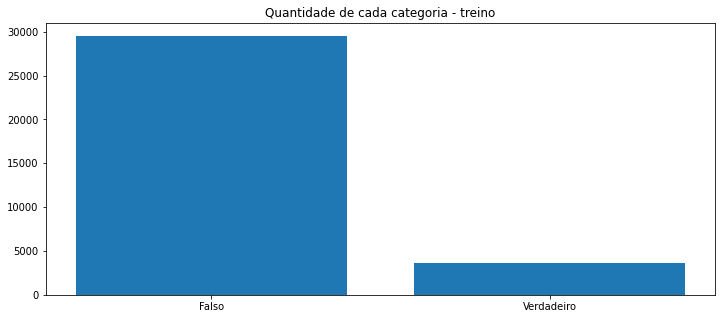

In [14]:
plt.figure(figsize=(12,5))
unicos, contagem = np.unique(y_treino, return_counts=True)
plt.bar(['Falso','Verdadeiro'], contagem)
plt.title("Quantidade de cada categoria - treino")
plt.show()

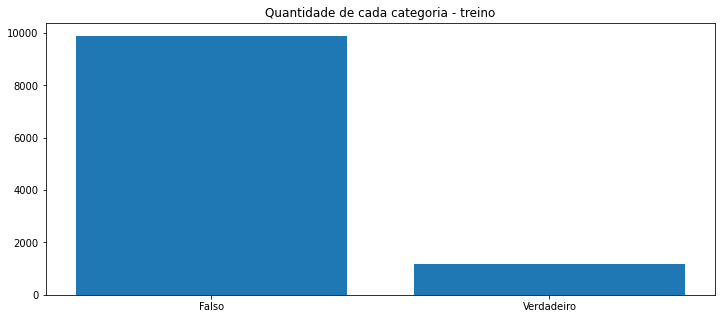

In [15]:
plt.figure(figsize=(12,5))
unicos, contagem = np.unique(y_validacao, return_counts=True)
plt.bar(['Falso','Verdadeiro'], contagem)
plt.title("Quantidade de cada categoria - treino")
plt.show()

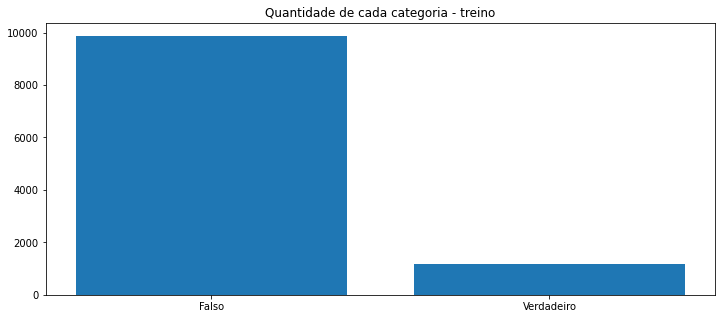

In [16]:
plt.figure(figsize=(12,5))
unicos, contagem = np.unique(y_teste, return_counts=True)
plt.bar(['Falso','Verdadeiro'], contagem)
plt.title("Quantidade de cada categoria - treino")
plt.show()

In [7]:
def plotarGrafico(historico,valor1,valor2,valor3,valor4):
    plt.figure(figsize=(10, 8))
    plt.plot(historico.history[valor1])
    plt.plot(historico.history[valor2])
    plt.title(valor3)
    plt.xlabel('Épocas')
    plt.ylabel(valor4)
    plt.legend(['Treino', 'Validação'])
    plt.show()

In [10]:
def executarModelo(modelo,x_treino,x_validacao,y_treino,y_validacao,nome):
  treino_erro,validaca_erro = [],[]
  epocas = 100
  melhor_epoca = None
  melhor_modelo = None
  erro_minimo_validacao = float('inf')

  for epoca in range(epocas):
    modelo.fit(x_treino,y_treino) 

    y_treino_resposta = modelo.predict(x_treino)
    y_validacao_resposta = modelo.predict(x_validacao)

    treino_erro.append(mean_squared_error(y_treino,y_treino_resposta,squared=True))
    validaca_erro.append(mean_squared_error(y_validacao,y_validacao_resposta,squared=True))

    if validaca_erro[-1:][0] < erro_minimo_validacao:
      erro_minimo_validacao = validaca_erro[-1:][0]
      melhor_epoca = epoca + 1
      melhor_modelo = modelo

  y_pred = melhor_modelo.predict(x_validacao)

  print(f'Acurácia do modelo na validação com melhor modelo é {round(accuracy_score(y_validacao, y_pred)*100,2)}%.')
  print(f'Precisão do modelo na validação com melhor modelo é {round(precision_score(y_validacao, y_pred, average="micro")*100,2)}%.')
  print(f'Recall do modelo na validação com melhor modelo é {round(recall_score(y_validacao, y_pred, average="micro")*100,2)}%.')
  print(f"Melhor época: {melhor_epoca}")

  plt.figure(figsize=(12,5))
  plt.title(nome)

  plt.plot(treino_erro)
  plt.plot(validaca_erro)
  plt.title(f'Função de custo vs Número de Épocas - {nome}')
  plt.xlabel('Épocas')
  plt.ylabel("Função de Custo (J)")
  plt.legend(['Treino', 'Validação'])

  plt.show()

  return melhor_modelo

Acurácia do modelo na validação com melhor modelo é 89.18%.
Precisão do modelo na validação com melhor modelo é 89.18%.
Recall do modelo na validação com melhor modelo é 89.18%.
Melhor época: 1


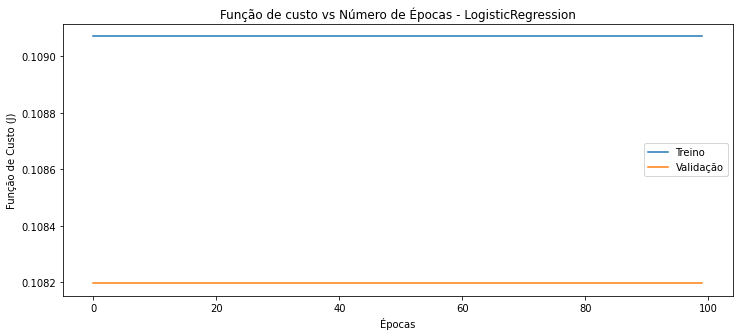

In [19]:
x_treino, x_validacao, x_teste, y_treino, y_validacao, y_teste = prepararDatasetScikitLearn(x, y)

modelo = executarModelo(LogisticRegression(solver="lbfgs", max_iter = 1,warm_start=True),x_treino,x_validacao,y_treino,y_validacao,'LogisticRegression')

filename = 'modelo1.sav'
pickle.dump(modelo, open(filename, 'wb'))

In [14]:
x_treino.shape

(33162, 96, 96)

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 flatten (Flatten)           (None, 9216)              0         
                                                                 
 dense (Dense)               (None, 300)               2765100   
                                                                 
 dense_1 (Dense)             (None, 100)               30100     
                                                                 
 dense_2 (Dense)             (None, 2)                 202       
                                                                 
Total params: 2,795,402
Trainable params: 2,795,402
Non-trainable params: 0
_________________________________________________________________
Epoch 1/15
130/130 [==============================] - 5s 22ms/step - loss: 0.9375 - accuracy: 0.8750 - val_loss: 0.4403 - val_accuracy: 0.8918
Epoch 2/15
130/130 [===============

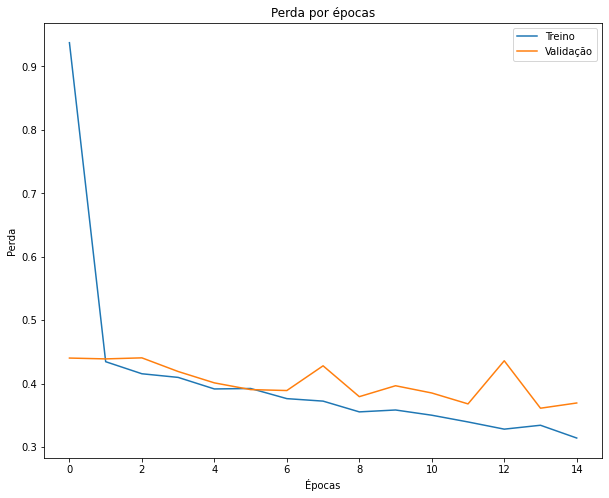

Acurácia do modelo na validação com melhor modelo é 88.71%.
Precisão do modelo na validação com melhor modelo é 88.71%.
Recall do modelo na validação com melhor modelo é 88.71%.


In [12]:
x_treino, x_validacao, x_teste, y_treino, y_validacao, y_teste = prepararDatasetKeras(x,y)

tamanho_batch = 256
epocas = 15
nome = 'modelo1.h5'

callbacks=[keras.callbacks.ModelCheckpoint(filepath=nome,verbose=0,save_best_only=True)]

kernel_initializer = tf.keras.initializers.GlorotUniform(seed=None)
bias_initializer = tf.keras.initializers.Ones()
regularizer = tf.keras.regularizers.l2(1e-4)

modelo = keras.Sequential(
    [
        keras.Input(shape=(img_size,img_size,)),
        layers.Flatten(),
        layers.Dense(300, activation="relu", kernel_initializer=kernel_initializer, bias_initializer=bias_initializer, kernel_regularizer=regularizer, bias_regularizer=regularizer, activity_regularizer=regularizer),
        layers.Dense(100, activation="relu", kernel_initializer=kernel_initializer, bias_initializer=bias_initializer, kernel_regularizer=regularizer, bias_regularizer=regularizer, activity_regularizer=regularizer),
        layers.Dense(2, activation="softmax", kernel_initializer=kernel_initializer, bias_initializer=bias_initializer, kernel_regularizer=regularizer, bias_regularizer=regularizer, activity_regularizer=regularizer),
    ]
)

modelo.summary()

modelo.compile(loss="sparse_categorical_crossentropy", optimizer=tf.keras.optimizers.Adam(learning_rate=3e-04, beta_1=0.9, beta_2=0.999, epsilon=1e-07), metrics=["accuracy"])

historico = modelo.fit(x_treino, y_treino, batch_size=tamanho_batch, epochs=epocas, validation_data=(x_validacao,y_validacao),validation_batch_size=tamanho_batch,callbacks=callbacks)

plotarGrafico(historico,"loss","val_loss","Perda por épocas","Perda")

modelo = keras.models.load_model(nome)

y_pred = modelo.predict(x_validacao)
y_pred = np.argmax(y_pred, axis=1)

print(f'Acurácia do modelo na validação com melhor modelo é {round(accuracy_score(y_validacao, y_pred)*100,2)}%.')
print(f'Precisão do modelo na validação com melhor modelo é {round(precision_score(y_validacao, y_pred, average="micro")*100,2)}%.')
print(f'Recall do modelo na validação com melhor modelo é {round(recall_score(y_validacao, y_pred, average="micro")*100,2)}%.')

Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 flatten_1 (Flatten)         (None, 9216)              0         
                                                                 
 dense_3 (Dense)             (None, 300)               2765100   
                                                                 
 dropout (Dropout)           (None, 300)               0         
                                                                 
 dense_4 (Dense)             (None, 100)               30100     
                                                                 
 dropout_1 (Dropout)         (None, 100)               0         
                                                                 
 dense_5 (Dense)             (None, 2)                 202       
                                                                 
Total params: 2,795,402
Trainable params: 2,795,402
No

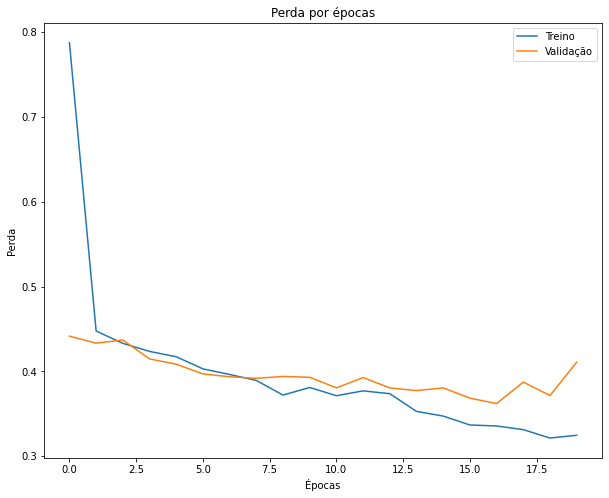

Acurácia do modelo na validação com melhor modelo é 88.61%.
Precisão do modelo na validação com melhor modelo é 88.61%.
Recall do modelo na validação com melhor modelo é 88.61%.


In [13]:
x_treino, x_validacao, x_teste, y_treino, y_validacao, y_teste = prepararDatasetKeras(x,y)

tamanho_batch = 256
epocas = 20
nome = 'modelo2.h5'

callbacks=[keras.callbacks.ModelCheckpoint(filepath=nome,verbose=0,save_best_only=True)]

kernel_initializer = tf.keras.initializers.GlorotUniform(seed=None)
bias_initializer = tf.keras.initializers.Ones()
regularizer = tf.keras.regularizers.l2(1e-4)

modelo = keras.Sequential(
    [
        keras.Input(shape=(img_size,img_size,)),
        layers.Flatten(),
        layers.Dense(300, activation="relu", kernel_initializer=kernel_initializer, bias_initializer=bias_initializer, kernel_regularizer=regularizer, bias_regularizer=regularizer, activity_regularizer=regularizer),
        layers.Dropout(0.1),
        layers.Dense(100, activation="relu", kernel_initializer=kernel_initializer, bias_initializer=bias_initializer, kernel_regularizer=regularizer, bias_regularizer=regularizer, activity_regularizer=regularizer),
        layers.Dropout(0.1),
        layers.Dense(2, activation="softmax", kernel_initializer=kernel_initializer, bias_initializer=bias_initializer, kernel_regularizer=regularizer, bias_regularizer=regularizer, activity_regularizer=regularizer),
    ]
)

modelo.summary()

modelo.compile(loss="sparse_categorical_crossentropy", optimizer=tf.keras.optimizers.Adam(learning_rate=3e-04, beta_1=0.9, beta_2=0.999, epsilon=1e-07), metrics=["accuracy"])

historico = modelo.fit(x_treino, y_treino, batch_size=tamanho_batch, epochs=epocas, validation_data=(x_validacao,y_validacao),validation_batch_size=tamanho_batch,callbacks=callbacks)

plotarGrafico(historico,"loss","val_loss","Perda por épocas","Perda")

modelo = keras.models.load_model(nome)

y_pred = modelo.predict(x_validacao)
y_pred = np.argmax(y_pred, axis=1)

print(f'Acurácia do modelo na validação com melhor modelo é {round(accuracy_score(y_validacao, y_pred)*100,2)}%.')
print(f'Precisão do modelo na validação com melhor modelo é {round(precision_score(y_validacao, y_pred, average="micro")*100,2)}%.')
print(f'Recall do modelo na validação com melhor modelo é {round(recall_score(y_validacao, y_pred, average="micro")*100,2)}%.')

Model: "sequential_4"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 batch_normalization_15 (Bat  (None, 96, 96, 1)        4         
 chNormalization)                                                
                                                                 
 conv2d_12 (Conv2D)          (None, 96, 96, 32)        320       
                                                                 
 batch_normalization_16 (Bat  (None, 96, 96, 32)       128       
 chNormalization)                                                
                                                                 
 conv2d_13 (Conv2D)          (None, 96, 96, 32)        9248      
                                                                 
 max_pooling2d_8 (MaxPooling  (None, 48, 48, 32)       0         
 2D)                                                             
                                                      

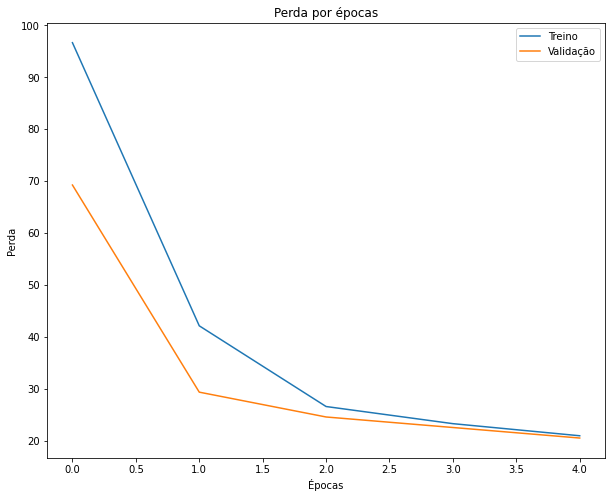

Acurácia do modelo na validação com melhor modelo é 89.44%.
Precisão do modelo na validação com melhor modelo é 89.44%.
Recall do modelo na validação com melhor modelo é 89.44%.


In [15]:
x_treino, x_validacao, x_teste, y_treino, y_validacao, y_teste = prepararDatasetKeras(x,y)

tamanho_batch = 256
epocas = 5
nome = 'modelo3.h5'

callbacks=[keras.callbacks.ModelCheckpoint(filepath=nome,verbose=0,save_best_only=True)]

kernel_initializer = tf.keras.initializers.GlorotUniform(seed=None)
bias_initializer = tf.keras.initializers.Ones()
regularizer = tf.keras.regularizers.l2(1e-4)

modelo = keras.Sequential(
    [
        keras.Input(shape=(img_size,img_size,1,)),
     
        layers.BatchNormalization(),
        layers.Conv2D(32, kernel_size=(3, 3), padding='same', activation="relu", kernel_initializer=kernel_initializer, bias_initializer=bias_initializer, kernel_regularizer=regularizer, bias_regularizer=regularizer, activity_regularizer=regularizer),
        layers.BatchNormalization(),
        layers.Conv2D(32, kernel_size=(3, 3), padding='same', activation="relu", kernel_initializer=kernel_initializer, bias_initializer=bias_initializer, kernel_regularizer=regularizer, bias_regularizer=regularizer, activity_regularizer=regularizer),
        layers.MaxPooling2D(pool_size=(2, 2)),
        layers.Dropout(0.3),

        layers.BatchNormalization(),
        layers.Conv2D(64, kernel_size=(3, 3), padding='same', activation="relu", kernel_initializer=kernel_initializer, bias_initializer=bias_initializer, kernel_regularizer=regularizer, bias_regularizer=regularizer, activity_regularizer=regularizer),
        layers.BatchNormalization(),
        layers.Conv2D(64, kernel_size=(3, 3), padding='same', activation="relu", kernel_initializer=kernel_initializer, bias_initializer=bias_initializer, kernel_regularizer=regularizer, bias_regularizer=regularizer, activity_regularizer=regularizer),
        layers.MaxPooling2D(pool_size=(2, 2)),
        layers.Dropout(0.3),
     
        layers.Flatten(),
        layers.Dense(128, activation="relu", kernel_initializer=kernel_initializer, bias_initializer=bias_initializer, kernel_regularizer=regularizer, bias_regularizer=regularizer, activity_regularizer=regularizer),
        layers.BatchNormalization(),
        layers.Dropout(0.3),
        layers.Dense(2, activation="softmax", kernel_initializer=kernel_initializer, bias_initializer=bias_initializer, kernel_regularizer=regularizer, bias_regularizer=regularizer, activity_regularizer=regularizer),
    ]
)

modelo.summary()

modelo.compile(loss="sparse_categorical_crossentropy", optimizer=tf.keras.optimizers.Adam(learning_rate=3e-04, beta_1=0.9, beta_2=0.999, epsilon=1e-07), metrics=["accuracy"])

historico = modelo.fit(x_treino, y_treino, batch_size=tamanho_batch, epochs=epocas, validation_data=(x_validacao,y_validacao),validation_batch_size=tamanho_batch,callbacks=callbacks)

plotarGrafico(historico,"loss","val_loss","Perda por épocas","Perda")

modelo = keras.models.load_model(nome)

y_pred = modelo.predict(x_validacao)
y_pred = np.argmax(y_pred, axis=1)

print(f'Acurácia do modelo na validação com melhor modelo é {round(accuracy_score(y_validacao, y_pred)*100,2)}%.')
print(f'Precisão do modelo na validação com melhor modelo é {round(precision_score(y_validacao, y_pred, average="micro")*100,2)}%.')
print(f'Recall do modelo na validação com melhor modelo é {round(recall_score(y_validacao, y_pred, average="micro")*100,2)}%.')

In [12]:
x_treino, x_validacao, x_teste, y_treino, y_validacao, y_teste = prepararDatasetScikitLearn(x,y)

modelo = LogisticRegression()
modelo.fit(x_treino, y_treino)

filename = 'modelo7.sav'
pickle.dump(modelo, open(filename, 'wb'))

y_pred = modelo.predict(x_validacao)

print(f'Acurácia do modelo na validação com melhor modelo é {round(accuracy_score(y_validacao, y_pred)*100,2)}%.')
print(f'Precisão do modelo na validação com melhor modelo é {round(precision_score(y_validacao, y_pred, average="micro")*100,2)}%.')
print(f'Recall do modelo na validação com melhor modelo é {round(recall_score(y_validacao, y_pred, average="micro")*100,2)}%.')

Acurácia do modelo na validação com melhor modelo é 87.74%.
Precisão do modelo na validação com melhor modelo é 87.74%.
Recall do modelo na validação com melhor modelo é 87.74%.


In [8]:
x_treino, x_validacao, x_teste, y_treino, y_validacao, y_teste = prepararDatasetScikitLearn(x,y)

modelo = RandomForestClassifier()
modelo.fit(x_treino, y_treino)

filename = 'modelo8.sav'
pickle.dump(modelo, open(filename, 'wb'))

y_pred = modelo.predict(x_validacao)

print(f'Acurácia do modelo na validação com melhor modelo é {round(accuracy_score(y_validacao, y_pred)*100,2)}%.')
print(f'Precisão do modelo na validação com melhor modelo é {round(precision_score(y_validacao, y_pred, average="micro")*100,2)}%.')
print(f'Recall do modelo na validação com melhor modelo é {round(recall_score(y_validacao, y_pred, average="micro")*100,2)}%.')

Acurácia do modelo na validação com melhor modelo é 84.54%.
Precisão do modelo na validação com melhor modelo é 84.54%.
Recall do modelo na validação com melhor modelo é 84.54%.


In [9]:
def matrixConfusao(modelo,x_teste,y_teste,nome,keras):
  if(keras):
    y_pred = modelo.predict(x_teste)
    y_pred = np.argmax(y_pred, axis=1)
  else:
    y_pred = modelo.predict(x_teste)

  print(f'Acurácia do modelo no teste com {nome} é {round(accuracy_score(y_teste, y_pred)*100,2)}%.')
  print(f'Precisão do modelo teste com {nome} é {round(precision_score(y_teste, y_pred, average="micro")*100,2)}%.')
  print(f'Recall do modelo teste com {nome} é {round(recall_score(y_teste, y_pred, average="micro")*100,2)}%.')

  n_features = 2

  label = ['Falso','Verdadeiro']

  cf_matrix = confusion_matrix(y_teste,y_pred)
  df_cm = pd.DataFrame(cf_matrix/cf_matrix.sum(axis=1).reshape(n_features,1), index=label, columns=label)

  list_texto = cf_matrix.tolist()
  for i in range(n_features):
    list_texto[i][i] = f"{list_texto[i][i]}/{(y_teste == i).sum()}"

  df_texto = pd.DataFrame(list_texto, index=label, columns=label).astype('string')

  sns.set(font_scale=1.4)
  fig, ax = plt.subplots(figsize=(18,15),dpi=65)
  fmt = lambda x,pos: '{:.0%}'.format(x)
  sns.heatmap(df_cm, annot=True, annot_kws={"size": 14,'va':'bottom'}, cmap='Blues', ax=ax, fmt='.2%',cbar_kws={'format': FuncFormatter(fmt)})
  sns.heatmap(df_cm, annot=df_texto, annot_kws={"size": 14,'va':'top'}, cmap='Blues',fmt='', ax=ax, cbar=False)

  plt.title(f"Matriz de Confusão da {nome}")
  plt.xlabel("Predito")
  plt.ylabel("Correto")

  plt.show()

Acurácia do modelo no teste com CNN é 89.14%.
Precisão do modelo teste com CNN é 89.14%.
Recall do modelo teste com CNN é 89.14%.


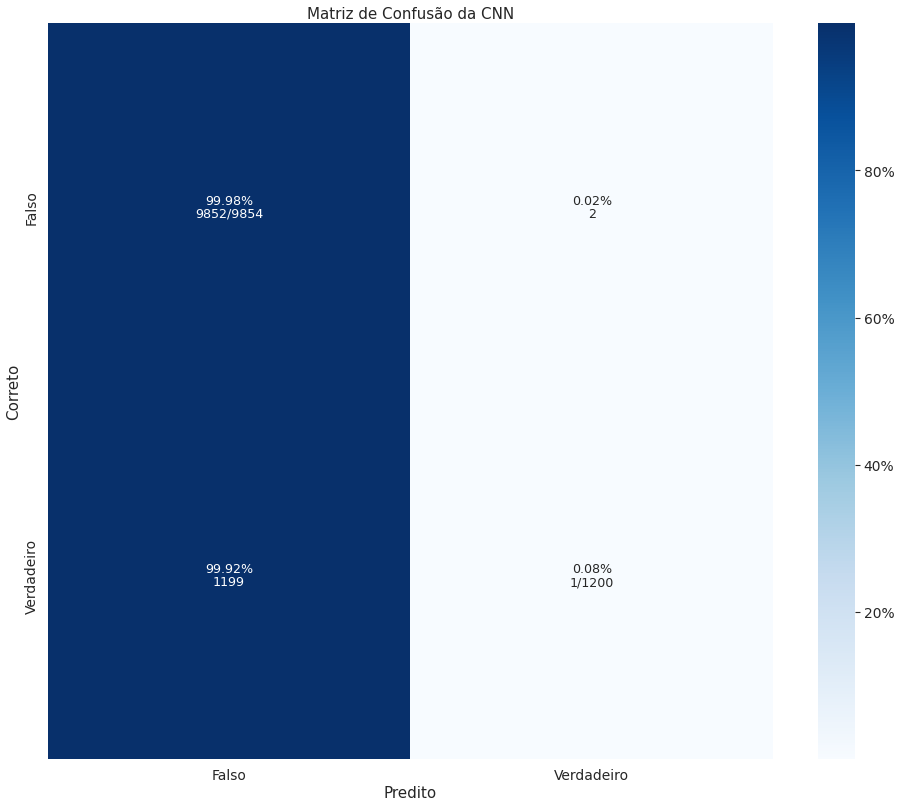

In [11]:
x_treino, x_validacao, x_teste, y_treino, y_validacao, y_teste = prepararDatasetKeras(x,y)

modelo = keras.models.load_model('modelo3.h5')

matrixConfusao(modelo,x_teste,y_teste,"CNN",True)

Acurácia do modelo no teste com LogisticRegression é 89.56%.
Precisão do modelo teste com LogisticRegression é 89.56%.
Recall do modelo teste com LogisticRegression é 89.56%.


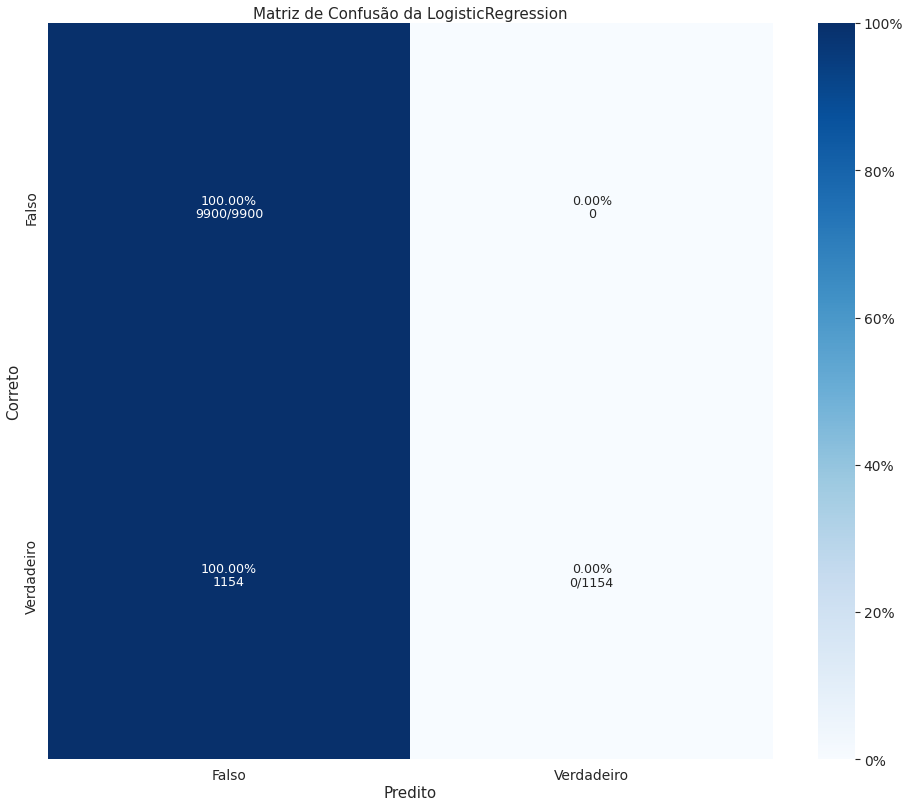

In [10]:
x_treino, x_validacao, x_teste, y_treino, y_validacao, y_teste = prepararDatasetScikitLearn(x,y)

filename = 'modelo1.sav' #Modelo com LogisticRegression
modelo = pickle.load(open(filename, 'rb'))

matrixConfusao(modelo,x_teste,y_teste,"LogisticRegression",False)